# Task 1C — Modeling

I forecast the **next hour** of PJME demand from the calendar, lag and rolling features
built in `src/preprocessing.py`. Because it's a time series I split **chronologically**
(train on the earlier years, test on the most recent ~20%) so the model is always judged
on the future, never on hours it could have peeked at. I compare a few models and tune
the strongest one.


In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

from src.preprocessing import build_features, time_split

sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "outputs" / "figures"
TARGET = "PJME_MW"

data = build_features("PJME")
train, test = time_split(data, test_size=0.2)

features = [c for c in data.columns if c != TARGET]
X_train, y_train = train[features], train[TARGET]
X_test, y_test = test[features], test[TARGET]

print("features:", features)
print(f"train: {len(train)} rows  ({train.index.min().date()} -> {train.index.max().date()})")
print(f"test:  {len(test)} rows  ({test.index.min().date()} -> {test.index.max().date()})")

features: ['hour', 'dayofweek', 'month', 'year', 'is_weekend', 'lag_1h', 'lag_24h', 'lag_168h', 'roll_mean_24h', 'roll_std_24h', 'roll_mean_168h', 'roll_std_168h']
train: 116179 rows  (2002-01-08 -> 2015-04-10)
test:  29045 rows  (2015-04-10 -> 2018-08-03)


## Baseline

Before any model I check the naive **persistence** forecast — just predict that the next
hour equals the last hour (`lag_1h`). Any real model has to beat this.


In [2]:
def score(y_true, pred, name):
    return {"model": name,
            "RMSE": root_mean_squared_error(y_true, pred),
            "MAE": mean_absolute_error(y_true, pred),
            "R2": r2_score(y_true, pred)}

results = [score(y_test, X_test["lag_1h"], "Naive (persistence)")]
print(results[0])

{'model': 'Naive (persistence)', 'RMSE': 1373.835208338132, 'MAE': 1069.9936650025822, 'R2': 0.9552033772363393}


## Experiments

Three models on the same features and split: linear regression, a random forest, and a
gradient-boosting regressor. RMSE and MAE are in MW, so lower is better.


In [3]:
lin = LinearRegression().fit(X_train, y_train)
results.append(score(y_test, lin.predict(X_test), "Linear regression"))

rf = RandomForestRegressor(n_estimators=100, max_depth=20, n_jobs=-1, random_state=1)
rf.fit(X_train, y_train)
results.append(score(y_test, rf.predict(X_test), "Random forest"))

gb = HistGradientBoostingRegressor(random_state=1)
gb.fit(X_train, y_train)
results.append(score(y_test, gb.predict(X_test), "Gradient boosting (default)"))

pd.DataFrame(results).round(2)

,model,RMSE,MAE,R2
0,Naive (persistence),1373.84,1069.99,0.96
1,Linear regression,1239.86,970.23,0.96
2,Random forest,413.58,298.86,1.00
3,Gradient boosting (default),455.12,345.89,1.00


## Hyperparameter tuning

Gradient boosting is the strongest family here, so I tune it with `GridSearchCV` over a
small grid. The cross-validation uses `TimeSeriesSplit` — each fold trains on the past
and validates on the next block, which respects the time order (a normal shuffled K-fold
would leak future information into training).


In [4]:
grid = {
    "learning_rate": [0.05, 0.1],
    "max_iter": [300, 600],
    "max_depth": [None, 8],
}
search = GridSearchCV(
    HistGradientBoostingRegressor(random_state=1),
    grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
search.fit(X_train, y_train)

print("best params:", search.best_params_)
print("best CV RMSE:", round(-search.best_score_, 2))

best = search.best_estimator_
results.append(score(y_test, best.predict(X_test), "Gradient boosting (tuned)"))

best params: {'learning_rate': 0.1, 'max_depth': None, 'max_iter': 600}
best CV RMSE: 420.6


## Experiment table

In [5]:
table = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
table.round(2)

,model,RMSE,MAE,R2
0,Gradient boosting (tuned),367.20,268.36,1.00
1,Random forest,413.58,298.86,1.00
2,Gradient boosting (default),455.12,345.89,1.00
3,Linear regression,1239.86,970.23,0.96
4,Naive (persistence),1373.84,1069.99,0.96


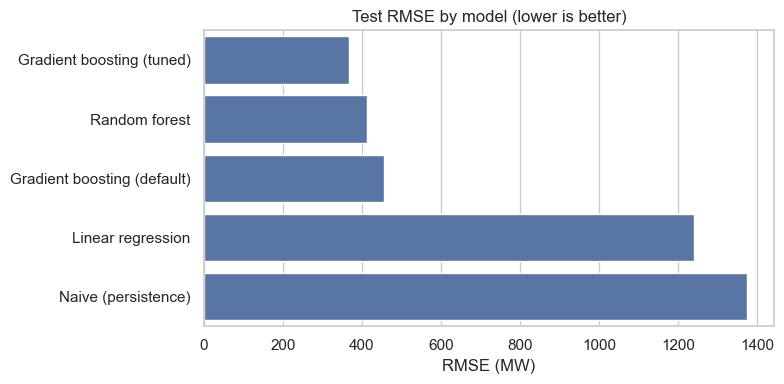

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=table, y="model", x="RMSE", ax=ax, color="#4C72B0")
ax.set(title="Test RMSE by model (lower is better)", xlabel="RMSE (MW)", ylabel="")
fig.tight_layout(); fig.savefig(FIG / "model_rmse.png", dpi=120); plt.show()

The tree models crush the linear baseline and the naive forecast. Tuning the gradient
booster gives the lowest test RMSE, so that's the model I keep. The interpretation lines
up with the EDA: the lag and rolling features carry most of the signal, and a non-linear
model exploits the interactions between them and the calendar.


## What the model relies on

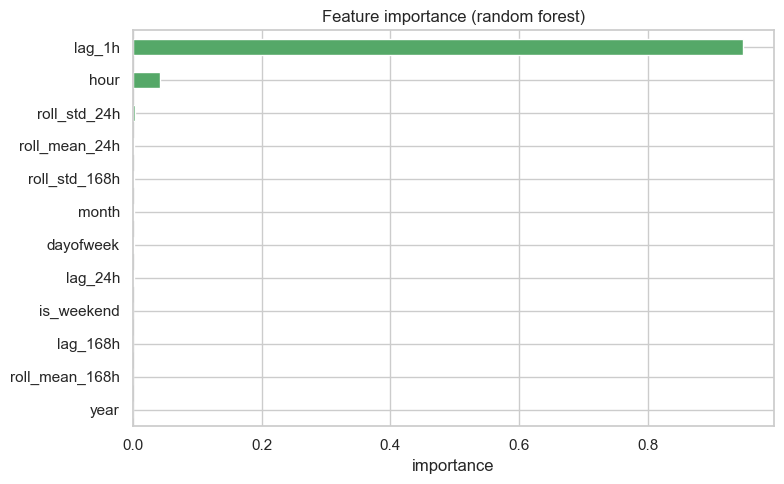

In [7]:
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot.barh(ax=ax, color="#55A868")
ax.set(title="Feature importance (random forest)", xlabel="importance")
fig.tight_layout(); fig.savefig(FIG / "feature_importance.png", dpi=120); plt.show()

As expected, `lag_1h` dominates — the last hour is by far the best predictor — followed
by the daily lag, rolling means and `hour`. This matches the strong autocorrelation I
found in Q3 and justifies the whole feature set.


## Forecast vs actual

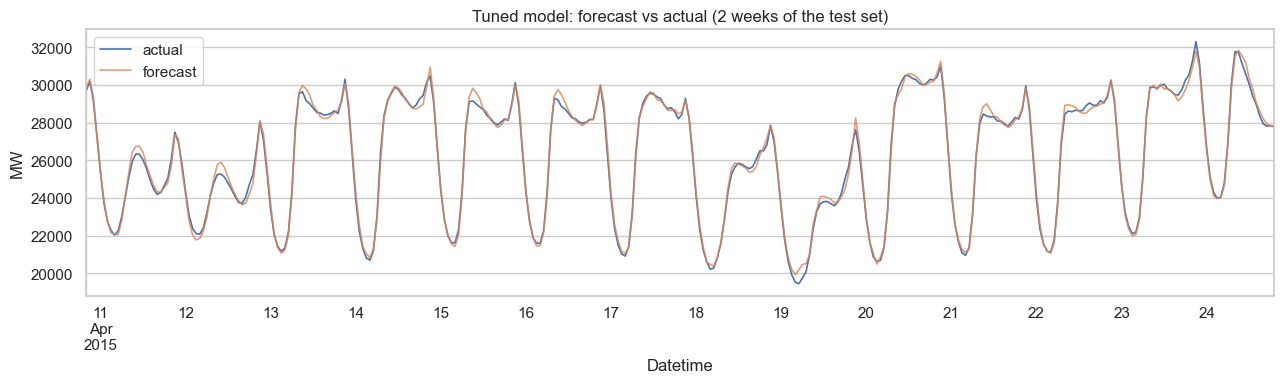

In [8]:
window = test.index[:24 * 14]          # first two weeks of the test period
pred = pd.Series(best.predict(X_test), index=test.index)

fig, ax = plt.subplots(figsize=(13, 4))
y_test.loc[window].plot(ax=ax, label="actual", lw=1.2)
pred.loc[window].plot(ax=ax, label="forecast", lw=1.2, alpha=0.8)
ax.set(title="Tuned model: forecast vs actual (2 weeks of the test set)", ylabel="MW")
ax.legend()
fig.tight_layout(); fig.savefig(FIG / "forecast_vs_actual.png", dpi=120); plt.show()

## Save the model for Task 4

In [9]:
models_dir = Path.cwd().parent / "models"
joblib.dump({"model": best, "features": features, "target": TARGET},
            models_dir / "pjme_forecaster.joblib")
print("saved models/pjme_forecaster.joblib")
print("best params:", search.best_params_)

saved models/pjme_forecaster.joblib
best params: {'learning_rate': 0.1, 'max_depth': None, 'max_iter': 600}


## Summary

- Chronological split, next-hour forecast, metrics in MW.
- Gradient boosting **tuned** wins; it beats the naive persistence baseline and linear
  regression by a wide margin (see the experiment table).
- `lag_1h`, `lag_24h` and the rolling means are the most important features, confirming
  the EDA.
- The trained model and its feature list are saved to `models/pjme_forecaster.joblib`
  for the Task 4 forecast script.
